In [1]:
!pip install gradio

Training on: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


Starting Training...
Epoch 1/15 - Loss: 0.1874
Epoch 2/15 - Loss: 0.0509
Epoch 3/15 - Loss: 0.0377
Epoch 4/15 - Loss: 0.0291
Epoch 5/15 - Loss: 0.0241
Epoch 6/15 - Loss: 0.0214
Epoch 7/15 - Loss: 0.0164
Epoch 8/15 - Loss: 0.0154
Epoch 9/15 - Loss: 0.0112
Epoch 10/15 - Loss: 0.0117
Epoch 11/15 - Loss: 0.0091
Epoch 12/15 - Loss: 0.0077
Epoch 13/15 - Loss: 0.0081
Epoch 14/15 - Loss: 0.0093
Epoch 15/15 - Loss: 0.0067

--- Evaluating Model ---


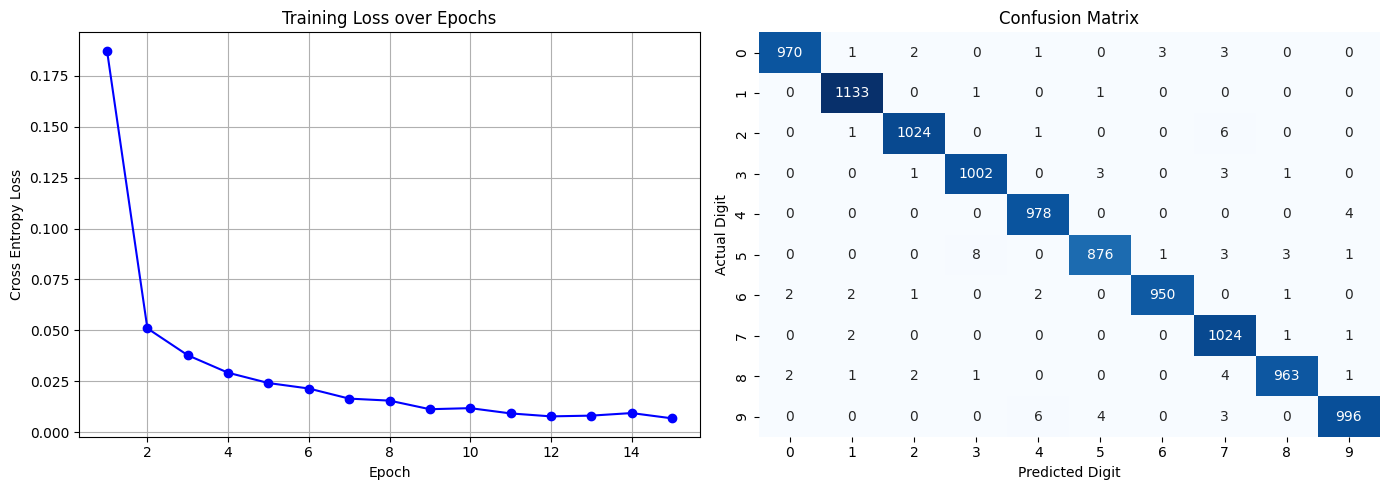


Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0     0.9959    0.9898    0.9928       980
           1     0.9939    0.9982    0.9960      1135
           2     0.9942    0.9922    0.9932      1032
           3     0.9901    0.9921    0.9911      1010
           4     0.9899    0.9959    0.9929       982
           5     0.9910    0.9821    0.9865       892
           6     0.9958    0.9916    0.9937       958
           7     0.9790    0.9961    0.9875      1028
           8     0.9938    0.9887    0.9913       974
           9     0.9930    0.9871    0.9901      1009

    accuracy                         0.9916     10000
   macro avg     0.9916    0.9914    0.9915     10000
weighted avg     0.9916    0.9916    0.9916     10000



In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3)
        self.fc1 = nn.Linear(64 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

model = CustomCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs =15
train_losses = []

print("Starting Training...")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss/len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

print("\n--- Evaluating Model ---")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        _, predicted = torch.max(output, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())


plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, marker='o', color='b')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
cm = confusion_matrix(all_targets, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Digit')
plt.ylabel('Actual Digit')

plt.tight_layout()
plt.show()

print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(all_targets, all_preds, digits=4))

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

model.eval()

model.to('cpu')

def predict_digit(img_dict):
    img = img_dict["composite"]
    img = img.resize((28, 28))
    img = img.convert('L')
    img_array = 255 - np.array(img)
    inverted_img = Image.fromarray(img_array)
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    input_tensor = transform(inverted_img).unsqueeze(0)

    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output[0], dim=0)

    confidences = {str(i): float(probabilities[i]) for i in range(10)}
    return confidences

demo = gr.Interface(
    fn=predict_digit,
    inputs=gr.Sketchpad(type="pil", label="Draw a digit (0-9) here!"),
    outputs=gr.Label(num_top_classes=3, label="PyTorch Prediction"),
    title="Colab PyTorch Digit Recognizer",
    description="Draw a number. The neural network I just trained will evaluate it in real-time.",
    live=True
)

demo.launch(debug=True, share=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f38544d89ae5a58301.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

content_type multipart/form-data; boundary=----WebKitFormBoundarybK3RQ0Fs2JJaKs9G
content_type multipart/form-data; boundary=----WebKitFormBoundaryfj5Y7JqSBg7cqBfQ
content_type multipart/form-data; boundary=----WebKitFormBoundaryvMkSgRSMVrIBs4uj


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

content_type multipart/form-data; boundary=----WebKitFormBoundaryr1orGiPAWFlVfaRL
content_type multipart/form-data; boundary=----WebKitFormBoundarypyhuzl1Bj07UBkhA
content_type multipart/form-data; boundary=----WebKitFormBoundaryjfKaQZqe1krrBOjl


...

content_type multipart/form-data; boundary=----WebKitFormBoundaryP76dswpt0bno959X
content_type multipart/form-data; boundary=----WebKitFormBoundaryM3BmJHZWiwzlEu3k
content_type multipart/form-data; boundary=----WebKitFormBoundaryHFPgwohnEXnQFgIo


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

content_type multipart/form-data; boundary=----WebKitFormBoundarygjRvMPIugCxpOMUL
content_type multipart/form-data; boundary=----WebKitFormBoundaryNEZHrYj75zLAqT8d
content_type multipart/form-data; boundary=----WebKitFormBoundaryFlsJBLnp5pbEdP4a


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

content_type multipart/form-data; boundary=----WebKitFormBoundaryezeoRYZWTkR1nAzB
content_type multipart/form-data; boundary=----WebKitFormBoundarygWfXDVIcLQJDh0jU
content_type multipart/form-data; boundary=----WebKitFormBoundaryfW5Fd9qrvf7xCVGO
